Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 662s 3s/step - accuracy: 0.8141 - loss: 0.3826 - val_accuracy: 0.8629 - val_loss: 0.3057
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 617s 3s/step - accuracy: 0.9277 - loss: 0.1769 - val_accuracy: 0.9274 - val_loss: 0.2229
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.9464 - loss: 0.1478 - val_accuracy: 0.9301 - val_loss: 0.1661
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 611s 3s/step - accuracy: 0.9580 - loss: 0.1175 - val_accuracy: 0.9288 - val_loss: 0.1557
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 611s 3s/step - accuracy: 0.9585 - loss: 0.1109 - val_accuracy: 0.8763 - val_loss: 0.2516
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 619s 3s/step - accuracy: 0.9604 - loss: 0.1077 - val_accuracy: 0.8737 - val_loss: 0.2588
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 602s 2s/step - accuracy: 0.9671 - loss: 0.0887 - val_accuracy: 0.8790 - val_loss: 0.2025
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.9617 - loss: 0.1035 - val_accu

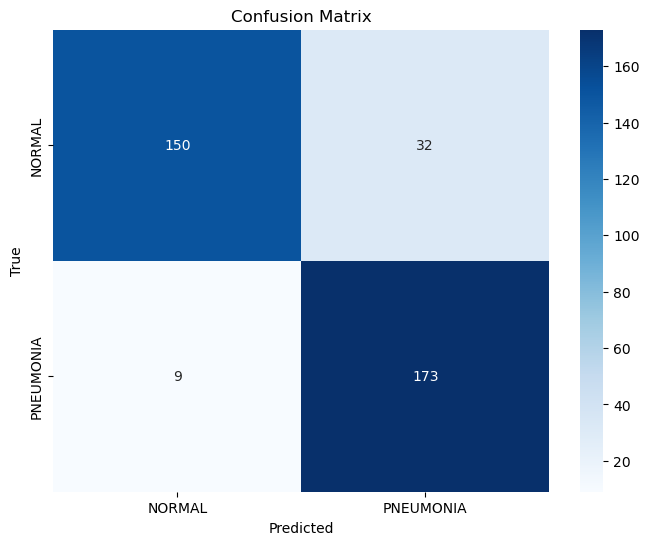

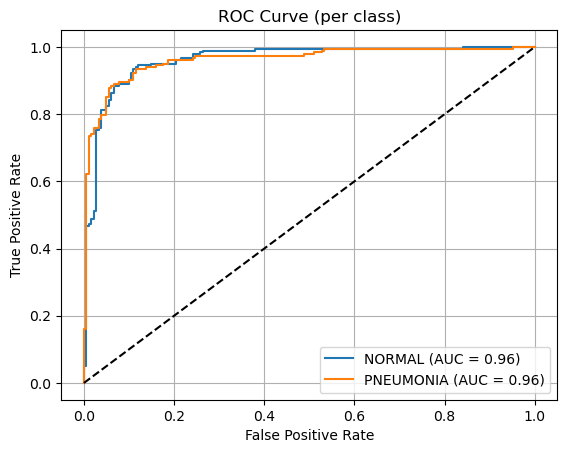

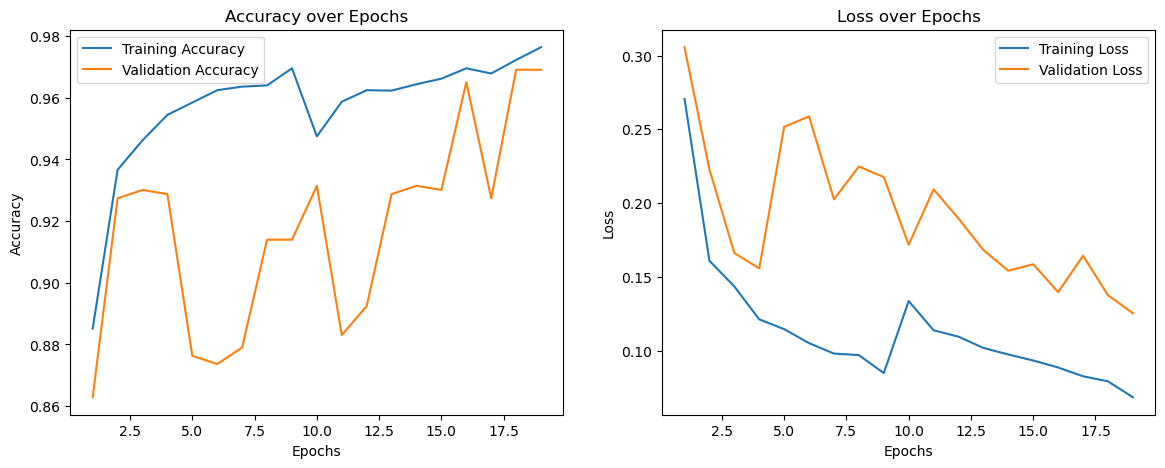

In [1]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])
# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])

In [3]:
import matplotlib.pyplot as plt

fig_dir = 'D:/Data-Chest-ray'
os.makedirs(fig_dir, exist_ok=True)

# Courbe d'apprentissage
def save_learning_curves(history_list, save_path):
    acc, val_acc, loss, val_loss = [], [], [], []
    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.savefig(os.path.join(save_path, 'learning_curves.png'))
    plt.close()

save_learning_curves([history_1, history_2], fig_dir)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'confusion_matrix.png'))
plt.close()
plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'roc_curve.png'))
plt.close()



In [5]:
# save
model_save_path = 'D:/Data-Chest-ray'
os.makedirs(model_save_path, exist_ok=True)

# Sauvegarder le modèle final
model.save(os.path.join(model_save_path, 'DenseNet201perfect_finetuned_model.keras'))
print("✅ Modèle enregistré avec succès dans pc.")

✅ Modèle enregistré avec succès dans pc.


Found 7750 images belonging to 2 classes.
Found 744 images belonging to 2 classes.
Found 364 images belonging to 2 classes.


C:\Users\Bsi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 682s 3s/step - accuracy: 0.6263 - loss: 0.8030 - val_accuracy: 0.8508 - val_loss: 0.4166
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 618s 3s/step - accuracy: 0.8454 - loss: 0.3624 - val_accuracy: 0.8495 - val_loss: 0.3328
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.8949 - loss: 0.2696 - val_accuracy: 0.8723 - val_loss: 0.2773
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 616s 3s/step - accuracy: 0.9152 - loss: 0.2232 - val_accuracy: 0.8831 - val_loss: 0.2692
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 609s 3s/step - accuracy: 0.9140 - loss: 0.2253 - val_accuracy: 0.8992 - val_loss: 0.2262
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 620s 3s/step - accuracy: 0.9288 - loss: 0.1990 - val_accuracy: 0.8804 - val_loss: 0.2222
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 612s 3s/step - accuracy: 0.9265 - loss: 0.1968 - val_accuracy: 0.8831 - val_loss: 0.2489
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 610s 3s/step - accuracy: 0.9386 - loss: 0.1848 - val_accu

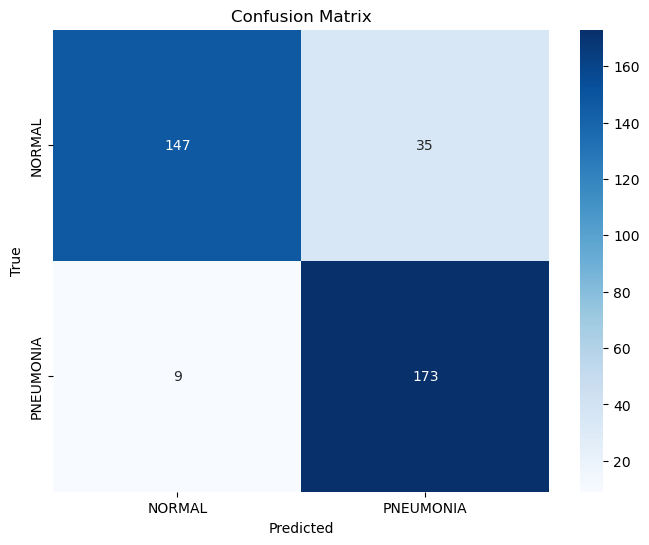

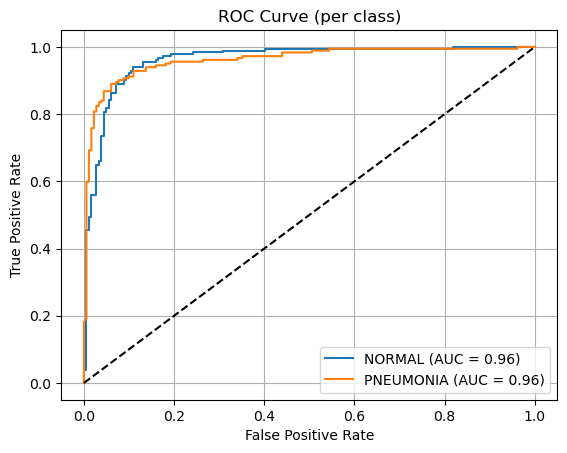

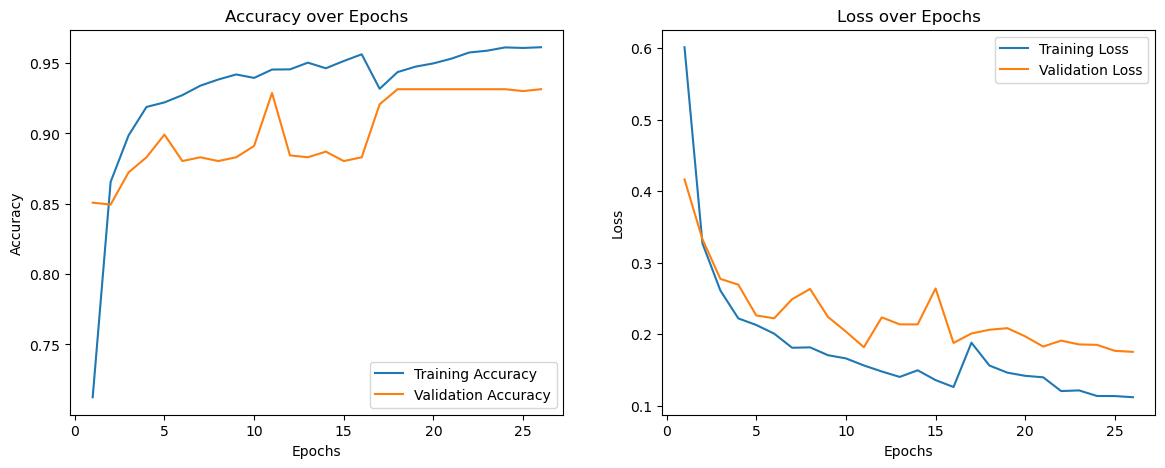

In [1]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.applications.densenet import preprocess_input
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
#preparation de donnees
train_dir = 'D:/Data-Chest-ray/train'
val_dir = 'D:/Data-Chest-ray/val'
test_dir = 'D:/Data-Chest-ray/test'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=15,
                                   zoom_range=0.1,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE,
                                          batch_size=BATCH_SIZE, class_mode='categorical')
test_gen = val_datagen.flow_from_directory(test_dir, target_size=IMG_SIZE,
                                           batch_size=1, class_mode='categorical', shuffle=False)
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.7),
    layers.Dense(train_gen.num_classes, activation='softmax')
])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
history_1 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=[early_stop])
# Fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

history_2 = model.fit(train_gen, validation_data=val_gen, epochs=10, callbacks=[early_stop])
# Prédictions
pred_probs = model.predict(test_gen)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes
target_names = list(test_gen.class_indices.keys())

# Rapport de classification
print(classification_report(y_true, y_pred, target_names=target_names))

# F1-score
f1 = f1_score(y_true, y_pred, average='macro')
print("F1-score (macro):", f1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Courbes ROC pour chaque classe
fpr, tpr, roc_auc = dict(), dict(), dict()
for i in range(len(target_names)):
    fpr[i], tpr[i], _ = roc_curve(test_gen.labels == i, pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(target_names)):
    plt.plot(fpr[i], tpr[i], label=f'{target_names[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (per class)')
plt.legend()
plt.grid(True)
plt.show()
def plot_learning_curves(history_list, labels):
    acc = []
    val_acc = []
    loss = []
    val_loss = []

    for hist in history_list:
        acc += hist.history['accuracy']
        val_acc += hist.history['val_accuracy']
        loss += hist.history['loss']
        val_loss += hist.history['val_loss']

    epochs_range = range(1, len(acc)+1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Appeler la fonction
plot_learning_curves([history_1, history_2], ['Phase 1', 'Phase 2'])